In [2]:
import os
from tensorflow.keras.utils import get_file

file_path = '../data/Jena_Climate'
os.makedirs(file_path, exist_ok=True)

donwloaded_dile = get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True,
    cache_dir=file_path 
)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
import numpy as np
import pandas as pd

DATA_PATH = '../data/jena_Climate/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv'

data = pd.read_csv(DATA_PATH)
data.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
df = data.drop(columns=['Date Time'])
df.isna().sum()


p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

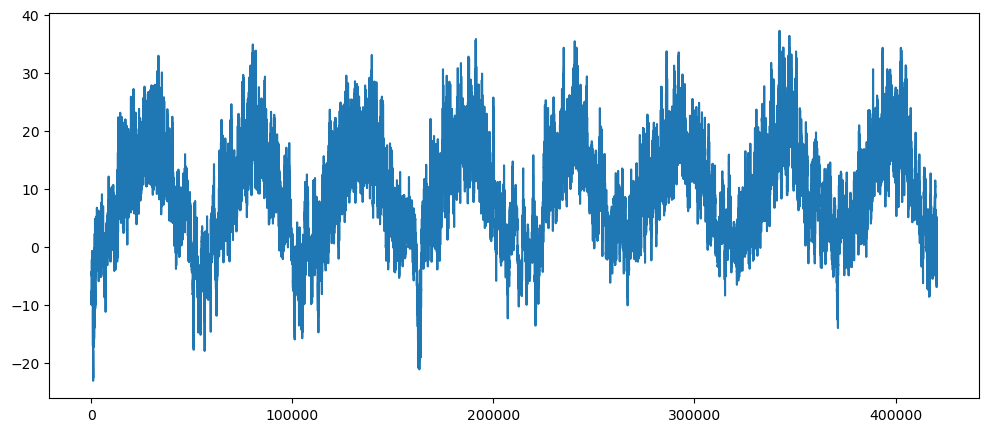

In [5]:
#Overall view of the temperature 
from matplotlib import pyplot as plt

temperature = df['T (degC)']
plt.figure(figsize=(12,5))
plt.plot(range(len(temperature)), temperature)
plt.show()

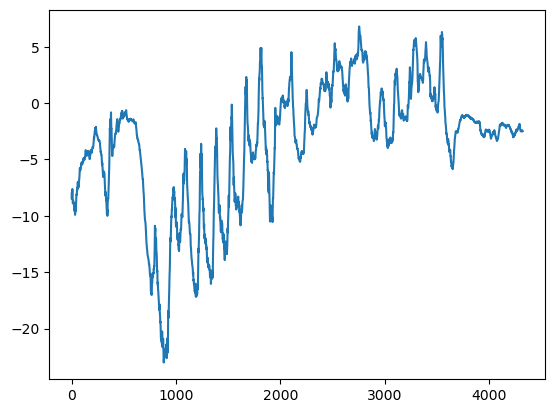

In [6]:
#Temperature over the firts 30 days
plt.plot(range(4320), temperature[:4320])
plt.show()

In [31]:
#Data preparation
from sklearn.preprocessing import StandardScaler
n_train_samples = int(0.5 * df.shape[0])
n_val_samples = int(0.25 * df.shape[0])
n_test_samples = df.shape[0] - n_train_samples - n_val_samples

data = df[:]
target = temperature[:]

scaler = StandardScaler()
scaler.fit(data[:n_train_samples].values)
train_data = scaler.transform(data[:n_train_samples].values)
val_data = scaler.transform(data[n_train_samples:n_train_samples + n_val_samples].values)
test_data = scaler.transform(data[n_train_samples + n_val_samples:].values)

In [ ]:
from tensorflow import keras

sampling_rate = 6 
sequence_length = 120
delay = sampling_rate*(sequence_length+24-1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    train_data[:-delay], 
    targets=target[delay:n_train_samples],
    sampling_rate=sampling_rate, 
    sequence_length=sequence_length,
    shuffle=True, 
    batch_size=batch_size, 
    start_index=0, 
    end_index=None
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    val_data[:-delay], 
    targets=target[n_train_samples:n_train_samples + n_val_samples],
    sampling_rate=sampling_rate, 
    sequence_length=sequence_length,
    shuffle=False, 
    batch_size=batch_size, 
    start_index=0, 
    end_index=None
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    test_data[:-delay], 
    targets=target[n_train_samples + n_val_samples + delay:],
    sampling_rate=sampling_rate, 
    sequence_length=sequence_length,
    shuffle=False, 
    batch_size=batch_size, 
    start_index=0, 
    end_index=None
)

In [34]:
for samples, targets in train_dataset:
    print('samples shape: ', samples.shape)
    print('targets shape: ', targets.shape)
    break

samples shape:  (256, 120, 14)
targets shape:  (256,)


In [35]:
#Testing a basic model with densely layer model
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, df.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_dense.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model('jena_dense.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 15.0380 - mae: 2.9968 - val_loss: 25.3641 - val_mae: 4.0338
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 9.9129 - mae: 2.4790 - val_loss: 22.7283 - val_mae: 3.7813
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 9.0319 - mae: 2.3675 - val_loss: 30.7875 - val_mae: 4.3859
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.4468 - mae: 2.2931 - val_loss: 25.6259 - val_mae: 4.0320
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.0568 - mae: 2.2402 - val_loss: 21.9791 - val_mae: 3.7124
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.7546 - mae: 2.2011 - val_loss: 24.2521 - val_mae: 3.9091
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.5164 - mae: 2.1644 - val_loss: 24.0395 - val_mae: 3.8624
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.3598 - mae: 2.1433 - val_loss: 23.7266 - val_mae: 3.8675
Epoch 9/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/

In [36]:
inputs = keras.Input(shape=(sequence_length, df.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks)
model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 21.6928 - mae: 3.6548 - val_loss: 20.3453 - val_mae: 3.6350
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 15.2255 - mae: 3.0964 - val_loss: 20.2928 - val_mae: 3.5877
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 13.8331 - mae: 2.9479 - val_loss: 20.6603 - val_mae: 3.6413
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 12.9157 - mae: 2.8465 - val_loss: 19.6929 - val_mae: 3.5310
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 12.2500 - mae: 2.7729 - val_loss: 20.2353 - val_mae: 3.5756
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 11.7794 - mae: 2.7164 - val_loss: 20.3903 - val_mae: 3.5747
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 11.3716 - mae: 2.6712 - val_loss: 23.5039 - val_mae: 3.8564
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 10.9901 - mae: 2.6259 - val_loss: 20.3087 - val_mae: 3.5767
Epoch 9/10
816/816 ━━━━━━━━━━━━━━

In [40]:
inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_lstm.keras',
                                    save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model('jena_lstm.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 47.0878 - mae: 5.0169 - val_loss: 24.8732 - val_mae: 3.9486
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 11.4317 - mae: 2.6222 - val_loss: 25.1828 - val_mae: 3.9805
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 10.1179 - mae: 2.4811 - val_loss: 24.6061 - val_mae: 3.9387
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 9.5545 - mae: 2.4108 - val_loss: 24.1956 - val_mae: 3.8947
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 9.1040 - mae: 2.3559 - val_loss: 23.1718 - val_mae: 3.8207
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 8.7251 - mae: 2.3090 - val_loss: 22.3525 - val_mae: 3.7529
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 8.4885 - mae: 2.2779 - val_loss: 21.8429 - val_mae: 3.6984
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 8.2773 - mae: 2.2508 - val_loss: 22.0286 - val_mae: 3.7200
Epoch 9/10
816/816 ━━━━━━━━━━

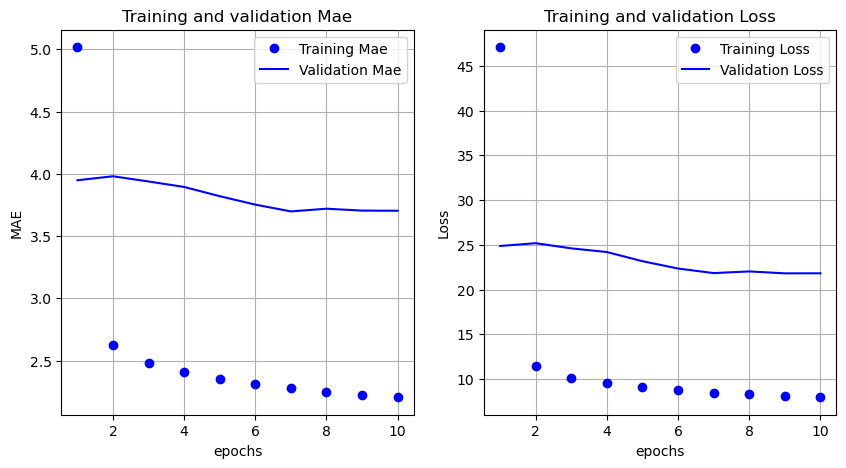

In [58]:
mae_lstm_model = history.history['mae']
val_mae_lstm_model = history.history['val_mae']
loss_lstm_model = history.history['loss']
val_loss_lstm_model = history.history['val_loss']

epochs = range(1, len(mae_lstm_model) + 1)

fig, ( axis1, axis2) = plt.subplots(1, 2, figsize=(10,5))

axis1.plot(epochs, mae_lstm_model, 'bo', label='Training Mae')
axis1.plot(epochs, val_mae_lstm_model, 'b', label='Validation Mae')
axis1.set_title('Training and validation Mae')
axis1.set_xlabel('epochs')
axis1.set_ylabel('MAE')
axis1.legend()
axis1.grid(True)

axis2.plot(epochs, loss_lstm_model, 'bo', label='Training Loss')
axis2.plot(epochs, val_loss_lstm_model, 'b', label='Validation Loss')
axis2.set_title('Training and validation Loss')
axis2.set_xlabel('epochs')
axis2.set_ylabel('Loss')
axis2.legend()
axis2.grid(True)